# Human annotator agreement

Compare instance annotations from two human annotators.

- Annotator A is treated as the ground truth.
- Annotator B is treated as the prediction.
- Evaluation will later use the existing instance-metrics runner.

In [7]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import tifffile


PROJECT_ROOT = next(
    path
    for path in (
        Path.cwd(),
        *Path.cwd().parents,
    )
    if (path / "pyproject.toml").is_file()
)

SRC_DIR = (
    PROJECT_ROOT
    / "src"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )


DATA_ROOT = (
    PROJECT_ROOT
    / "data"
    / "double_annotations"
)

IMAGES_DIR = DATA_ROOT / "images"
ANNOTATOR_A_DIR = DATA_ROOT / "annotator_a"
ANNOTATOR_B_DIR = DATA_ROOT / "annotator_b"

for directory in [
    IMAGES_DIR,
    ANNOTATOR_A_DIR,
    ANNOTATOR_B_DIR,
]:
    if not directory.is_dir():
        raise FileNotFoundError(directory)

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Images:", IMAGES_DIR)
print("Annotator A:", ANNOTATOR_A_DIR)
print("Annotator B:", ANNOTATOR_B_DIR)

Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2
Source directory: c:\Users\abd93000\PycharmProjects\cnt_project_v2\src
Images: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\double_annotations\images
Annotator A: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\double_annotations\annotator_a
Annotator B: c:\Users\abd93000\PycharmProjects\cnt_project_v2\data\double_annotations\annotator_b


### Find the TIFF files

In [8]:
def find_tiff_files(directory):
    return sorted(
        path
        for path in directory.iterdir()
        if path.is_file()
        and path.suffix.lower() in {
            ".tif",
            ".tiff",
        }
    )


image_paths = find_tiff_files(
    IMAGES_DIR
)

annotator_a_paths = find_tiff_files(
    ANNOTATOR_A_DIR
)

annotator_b_paths = find_tiff_files(
    ANNOTATOR_B_DIR
)

print("Original images:", len(image_paths))
print("Annotator A masks:", len(annotator_a_paths))
print("Annotator B masks:", len(annotator_b_paths))

Original images: 12
Annotator A masks: 12
Annotator B masks: 12


### Pair files by filename stem

In [9]:
def index_by_stem(paths):
    index = {}

    for path in paths:
        key = path.stem.casefold()

        if key in index:
            raise RuntimeError(
                f"Duplicate filename stem: {path.stem}"
            )

        index[key] = path

    return index


image_index = index_by_stem(
    image_paths
)

annotator_a_index = index_by_stem(
    annotator_a_paths
)

annotator_b_index = index_by_stem(
    annotator_b_paths
)


image_keys = set(image_index)
annotator_a_keys = set(annotator_a_index)
annotator_b_keys = set(annotator_b_index)

print(
    "Only in images:",
    sorted(
        image_keys
        - annotator_a_keys
        - annotator_b_keys
    ),
)

print(
    "Images missing from annotator A:",
    sorted(
        image_keys
        - annotator_a_keys
    ),
)

print(
    "Images missing from annotator B:",
    sorted(
        image_keys
        - annotator_b_keys
    ),
)

print(
    "Masks in A without an image:",
    sorted(
        annotator_a_keys
        - image_keys
    ),
)

print(
    "Masks in B without an image:",
    sorted(
        annotator_b_keys
        - image_keys
    ),
)

Only in images: []
Images missing from annotator A: []
Images missing from annotator B: ['400-1293-21_3_0_20230206211107', '400-1605-w7_map_00028_bottom_left', '400-1605-w7_map_00028_top_left', '400-1605-w8_map_00006_bottom_left', '400-1605-w8_map_00006_bottom_right', '400-1605-w8_map_00006_top_right', '400-1605-w8_map_00038_bottom_right']
Masks in A without an image: []
Masks in B without an image: ['400-1293-21_3_0_20230206211107_lab', '400-1605-w7_map_00028_1', '400-1605-w7_map_00028_3', '400-1605-w8_map_00006_2', '400-1605-w8_map_00006_3', '400-1605-w8_map_00006_4', '400-1605-w8_map_00038_4']


In [10]:
QUADRANT_SUFFIXES = {
    "_top_left": "_1",
    "_top_right": "_2",
    "_bottom_left": "_3",
    "_bottom_right": "_4",
}


def pairing_key(path):
    key = path.stem.casefold()

    if key.endswith("_lab"):
        key = key[:-4]

    for directional_suffix, numeric_suffix in (
        QUADRANT_SUFFIXES.items()
    ):
        if key.endswith(
            directional_suffix
        ):
            key = (
                key[
                    :-len(
                        directional_suffix
                    )
                ]
                + numeric_suffix
            )
            break

    return key


def index_by_pairing_key(paths):
    index = {}

    for path in paths:
        key = pairing_key(path)

        if key in index:
            raise RuntimeError(
                "Filename normalization collision: "
                f"{index[key].name} and {path.name} "
                f"both map to {key}."
            )

        index[key] = path

    return index


image_index = index_by_pairing_key(
    image_paths
)

annotator_a_index = index_by_pairing_key(
    annotator_a_paths
)

annotator_b_index = index_by_pairing_key(
    annotator_b_paths
)


image_keys = set(image_index)
annotator_a_keys = set(annotator_a_index)
annotator_b_keys = set(annotator_b_index)

print(
    "Images missing from annotator A:",
    sorted(
        image_keys
        - annotator_a_keys
    ),
)

print(
    "Images missing from annotator B:",
    sorted(
        image_keys
        - annotator_b_keys
    ),
)

print(
    "Annotator A masks without images:",
    sorted(
        annotator_a_keys
        - image_keys
    ),
)

print(
    "Annotator B masks without images:",
    sorted(
        annotator_b_keys
        - image_keys
    ),
)


if not (
    image_keys
    == annotator_a_keys
    == annotator_b_keys
):
    raise RuntimeError(
        "Three-way pairing still failed after "
        "normalizing the known filename suffixes."
    )

paired_keys = sorted(
    image_keys
)

print()
print(
    "PASS: paired images:",
    len(paired_keys),
)

pairing_df = pd.DataFrame(
    [
        {
            "pairing_key": key,
            "image": image_index[key].name,
            "annotator_a": (
                annotator_a_index[key].name
            ),
            "annotator_b": (
                annotator_b_index[key].name
            ),
        }
        for key in paired_keys
    ]
)

display(pairing_df)

Images missing from annotator A: []
Images missing from annotator B: []
Annotator A masks without images: []
Annotator B masks without images: []

PASS: paired images: 12


,pairing_key,image,annotator_a,annotator_b
0,400-1093-w14-c-1-p1-10sp-15flow_left,400-1093-w14-c-1-p1-10sp-15flow_left.tif,400-1093-w14-c-1-p1-10sp-15flow_left.tif,400-1093-w14-c-1-p1-10sp-15flow_left.tif
1,400-1093-w17-c1p3-20sp-03flow_right,400-1093-w17-c1p3-20sp-03flow_right.tif,400-1093-w17-c1p3-20sp-03flow_right.tif,400-1093-w17-c1p3-20sp-03flow_right.tif
2,400-1293-18_cd_c11k4r9_fl1_0sp9_image_left,400-1293-18_cd_c11k4r9_fl1_0sp9_image_left.tif,400-1293-18_cd_c11k4r9_fl1_0sp9_image_left.tif,400-1293-18_cd_c11k4r9_fl1_0sp9_image_left.tif
3,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_left,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_left.tif,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_left.tif,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_left.tif
4,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif
5,400-1293-21_3_0_20230206211107,400-1293-21_3_0_20230206211107.tif,400-1293-21_3_0_20230206211107.tif,400-1293-21_3_0_20230206211107_lab.tif
6,400-1605-w7_map_00028_1,400-1605-W7_map_00028_top_left.tif,400-1605-W7_map_00028_top_left.tif,400-1605-W7_map_00028_1.tif
7,400-1605-w7_map_00028_3,400-1605-W7_map_00028_bottom_left.tif,400-1605-W7_map_00028_bottom_left.tif,400-1605-W7_map_00028_3.tif
8,400-1605-w8_map_00006_2,400-1605-W8_map_00006_top_right.tif,400-1605-W8_map_00006_top_right.tif,400-1605-W8_map_00006_2.tif
9,400-1605-w8_map_00006_3,400-1605-W8_map_00006_bottom_left.tif,400-1605-W8_map_00006_bottom_left.tif,400-1605-W8_map_00006_3.tif


## Convert both annotators’ TIFF masks to lossless COCO RLE

In [ ]:
import json
import shutil
import tempfile

from cnt_project.coco.convert import (
    convert_tif_annotations_to_rle_json,
)


OUTPUT_ROOT = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "human_annotator_agreement"
)

INFERENCE_DIR = (
    OUTPUT_ROOT
    / "inference"
)

ANNOTATOR_A_RLE_PATH = (
    INFERENCE_DIR
    / "annotator_a_annotations_rle.json"
)

ANNOTATOR_B_RLE_PATH = (
    INFERENCE_DIR
    / "annotator_b_annotations_rle.json"
)


INFERENCE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


canonical_filenames = [
    f"{image_index[key].stem}.tif"
    for key in paired_keys
]


# --------------------------------------------------------------
# Reuse existing RLE files if they have already been generated.
# --------------------------------------------------------------

rle_files_exist = (
    ANNOTATOR_A_RLE_PATH.is_file()
    and ANNOTATOR_B_RLE_PATH.is_file()
)


if rle_files_exist:
    print(
        "RLE annotation files already exist. "
        "Skipping conversion."
    )

    with ANNOTATOR_A_RLE_PATH.open(
        "r",
        encoding="utf-8",
    ) as file:
        annotator_a_coco = json.load(file)

    with ANNOTATOR_B_RLE_PATH.open(
        "r",
        encoding="utf-8",
    ) as file:
        annotator_b_coco = json.load(file)


else:
    # Do not silently continue if only one of the
    # two expected files exists.
    existing_files = [
        path
        for path in [
            ANNOTATOR_A_RLE_PATH,
            ANNOTATOR_B_RLE_PATH,
        ]
        if path.exists()
    ]

    if existing_files:
        raise RuntimeError(
            "Only part of the expected RLE output exists. "
            "Delete the existing partial output before "
            "regenerating:\n"
            + "\n".join(
                str(path)
                for path in existing_files
            )
        )

    print(
        "RLE annotation files not found. "
        "Generating them..."
    )

    with tempfile.TemporaryDirectory() as temporary_root:
        temporary_root = Path(
            temporary_root
        )

        temporary_a = (
            temporary_root
            / "annotator_a"
        )

        temporary_b = (
            temporary_root
            / "annotator_b"
        )

        temporary_a.mkdir()
        temporary_b.mkdir()

        for key, canonical_filename in zip(
            paired_keys,
            canonical_filenames,
        ):
            shutil.copy2(
                annotator_a_index[key],
                temporary_a
                / canonical_filename,
            )

            shutil.copy2(
                annotator_b_index[key],
                temporary_b
                / canonical_filename,
            )

        annotator_a_coco = (
            convert_tif_annotations_to_rle_json(
                temporary_a,
                ANNOTATOR_A_RLE_PATH,
                selected_filenames=(
                    canonical_filenames
                ),
                preserve_tif_filenames=True,
                category_id=1,
            )
        )

        annotator_b_coco = (
            convert_tif_annotations_to_rle_json(
                temporary_b,
                ANNOTATOR_B_RLE_PATH,
                selected_filenames=(
                    canonical_filenames
                ),
                preserve_tif_filenames=True,
                category_id=1,
            )
        )


print()
print(
    "Annotator A RLE:",
    ANNOTATOR_A_RLE_PATH,
)

print(
    "Annotator B RLE:",
    ANNOTATOR_B_RLE_PATH,
)

FileExistsError: Output already exists: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\human_annotator_agreement\inference\annotator_a_annotations_rle.json

### validate the generated coco masks with the tif files 

In [12]:
from collections import Counter

from cnt_project.evaluation.inputs.coco_instances import (
    load_coco_rle_instance_pairs,
)


decoded_images = load_coco_rle_instance_pairs(
    ground_truth_json_path=(
        ANNOTATOR_A_RLE_PATH
    ),
    prediction_json_path=(
        ANNOTATOR_B_RLE_PATH
    ),
    prediction_score_threshold=0.0,
)


def extract_tiff_objects(mask_path):
    label_mask = np.asarray(
        tifffile.imread(mask_path)
    )

    labels = np.unique(label_mask)
    labels = labels[labels != 0]

    return tuple(
        label_mask == label
        for label in labels
    )


def mask_signature(mask):
    mask = np.asarray(
        mask,
        dtype=bool,
    )

    return (
        mask.shape,
        mask.tobytes(),
    )


def compare_object_sets(
    *,
    original_masks,
    decoded_masks,
    filename,
    annotator_name,
):
    original_signatures = Counter(
        mask_signature(mask)
        for mask in original_masks
    )

    decoded_signatures = Counter(
        mask_signature(mask)
        for mask in decoded_masks
    )

    missing_objects = (
        original_signatures
        - decoded_signatures
    )

    extra_objects = (
        decoded_signatures
        - original_signatures
    )

    identical = (
        not missing_objects
        and not extra_objects
    )

    return {
        "filename": filename,
        "annotator": annotator_name,
        "tiff_object_count": len(
            original_masks
        ),
        "runner_object_count": len(
            decoded_masks
        ),
        "pixel_identical_objects": (
            sum(
                (
                    original_signatures
                    & decoded_signatures
                ).values()
            )
        ),
        "missing_from_runner": sum(
            missing_objects.values()
        ),
        "extra_in_runner": sum(
            extra_objects.values()
        ),
        "all_objects_identical": identical,
    }


comparison_rows = []


for decoded_image in decoded_images:
    filename = Path(
        decoded_image.filename
    ).name

    key = pairing_key(
        Path(filename)
    )

    original_a_masks = extract_tiff_objects(
        annotator_a_index[key]
    )

    original_b_masks = extract_tiff_objects(
        annotator_b_index[key]
    )

    comparison_rows.append(
        compare_object_sets(
            original_masks=original_a_masks,
            decoded_masks=(
                decoded_image.ground_truth_masks
            ),
            filename=filename,
            annotator_name="Annotator A",
        )
    )

    comparison_rows.append(
        compare_object_sets(
            original_masks=original_b_masks,
            decoded_masks=(
                decoded_image.prediction_masks
            ),
            filename=filename,
            annotator_name="Annotator B",
        )
    )


runner_decode_comparison_df = pd.DataFrame(
    comparison_rows
)

display(
    runner_decode_comparison_df
)

,filename,annotator,tiff_object_count,runner_object_count,pixel_identical_objects,missing_from_runner,extra_in_runner,all_objects_identical
0,400-1093-w14-c-1-p1-10sp-15flow_left.tif,Annotator A,290,290,290,0,0,True
1,400-1093-w14-c-1-p1-10sp-15flow_left.tif,Annotator B,346,346,346,0,0,True
2,400-1093-w17-c1p3-20sp-03flow_right.tif,Annotator A,309,309,309,0,0,True
3,400-1093-w17-c1p3-20sp-03flow_right.tif,Annotator B,350,350,350,0,0,True
4,400-1293-18_cd_c11k4r9_fl1_0sp9_image_left.tif,Annotator A,258,258,258,0,0,True
5,400-1293-18_cd_c11k4r9_fl1_0sp9_image_left.tif,Annotator B,270,270,270,0,0,True
6,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_left.tif,Annotator A,320,320,320,0,0,True
7,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_left.tif,Annotator B,323,323,323,0,0,True
8,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif,Annotator A,297,297,297,0,0,True
9,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif,Annotator B,331,331,331,0,0,True


Images loaded by runner: 12
Comparisons performed: 24
TIFF objects: 3955
Runner-decoded objects: 3955
Pixel-identical objects: 3955

PASS: every object decoded through the evaluation runner is pixel-identical to its corresponding TIFF instance.


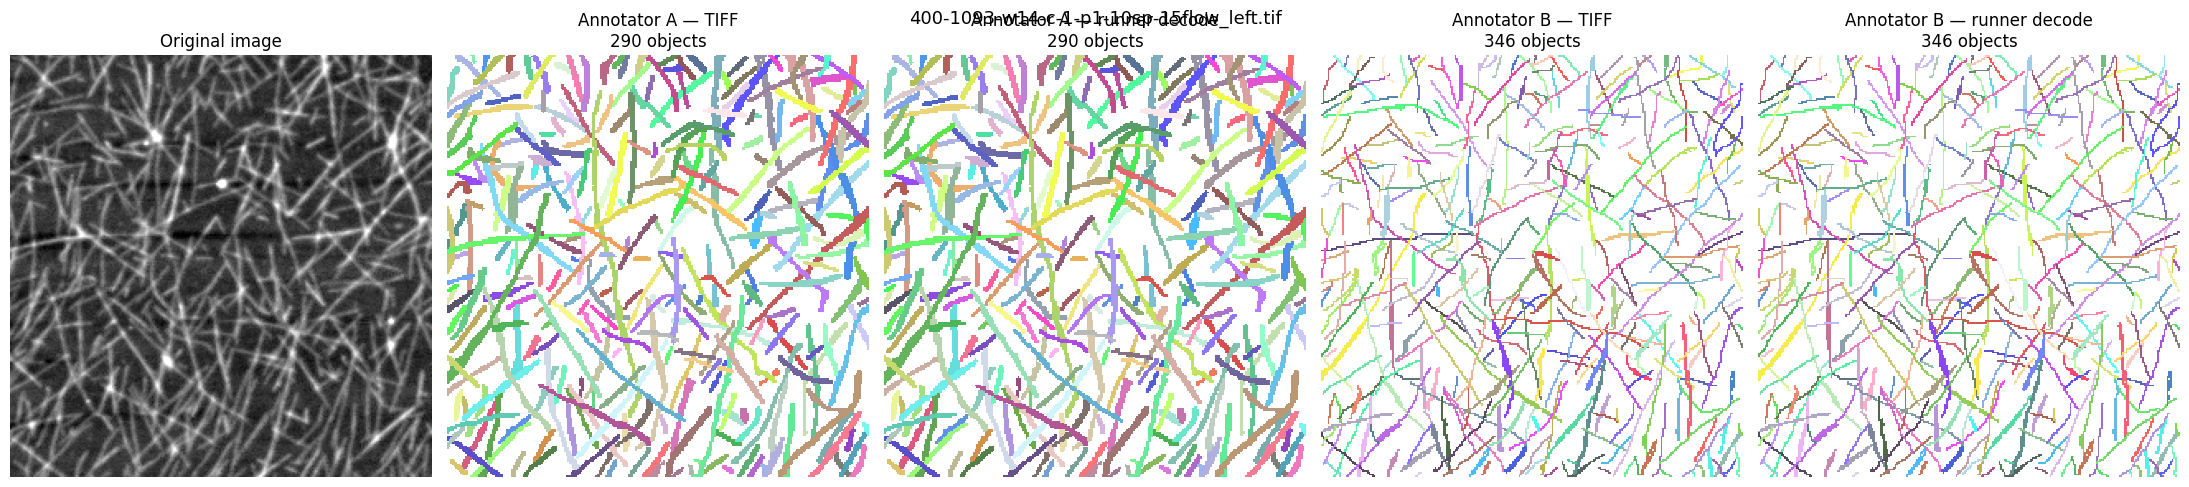

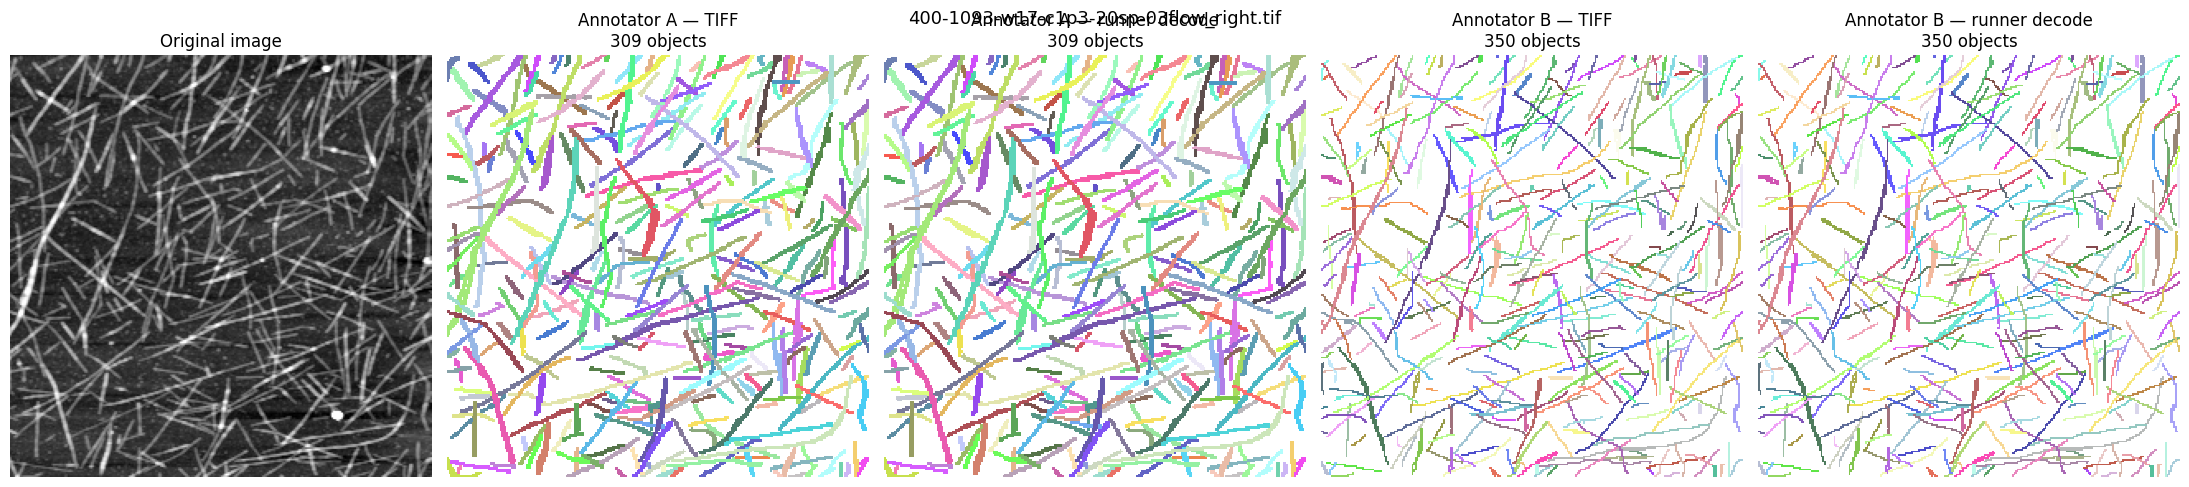

In [13]:
failed_rows = (
    runner_decode_comparison_df.loc[
        ~runner_decode_comparison_df[
            "all_objects_identical"
        ]
    ]
)


print(
    "Images loaded by runner:",
    len(decoded_images),
)

print(
    "Comparisons performed:",
    len(
        runner_decode_comparison_df
    ),
)

print(
    "TIFF objects:",
    runner_decode_comparison_df[
        "tiff_object_count"
    ].sum(),
)

print(
    "Runner-decoded objects:",
    runner_decode_comparison_df[
        "runner_object_count"
    ].sum(),
)

print(
    "Pixel-identical objects:",
    runner_decode_comparison_df[
        "pixel_identical_objects"
    ].sum(),
)


if not failed_rows.empty:
    display(failed_rows)

    raise RuntimeError(
        f"{len(failed_rows)} image/annotator "
        "comparisons contain masks that are not "
        "pixel-identical."
    )


print()
print(
    "PASS: every object decoded through the "
    "evaluation runner is pixel-identical to "
    "its corresponding TIFF instance."
)
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


NUMBER_OF_EXAMPLES = 2

rng = np.random.default_rng(42)

object_colors = np.vstack(
    [
        np.array([[0.0, 0.0, 0.0, 0.0]]),
        np.column_stack(
            [
                rng.uniform(
                    0.15,
                    1.0,
                    size=(3000, 3),
                ),
                np.full(3000, 0.85),
            ]
        ),
    ]
)

instance_colormap = ListedColormap(
    object_colors
)


def masks_to_label_image(
    masks,
    image_shape,
):
    label_image = np.zeros(
        image_shape,
        dtype=np.int32,
    )

    for label, mask in enumerate(
        masks,
        start=1,
    ):
        label_image[
            np.asarray(mask, dtype=bool)
        ] = label

    return label_image


for decoded_image in decoded_images[
    :NUMBER_OF_EXAMPLES
]:
    filename = Path(
        decoded_image.filename
    ).name

    key = pairing_key(
        Path(filename)
    )

    original_image = np.asarray(
        tifffile.imread(
            image_index[key]
        )
    )

    tiff_a_masks = extract_tiff_objects(
        annotator_a_index[key]
    )

    tiff_b_masks = extract_tiff_objects(
        annotator_b_index[key]
    )

    image_shape = original_image.shape[:2]

    tiff_a_labels = masks_to_label_image(
        tiff_a_masks,
        image_shape,
    )

    decoded_a_labels = masks_to_label_image(
        decoded_image.ground_truth_masks,
        image_shape,
    )

    tiff_b_labels = masks_to_label_image(
        tiff_b_masks,
        image_shape,
    )

    decoded_b_labels = masks_to_label_image(
        decoded_image.prediction_masks,
        image_shape,
    )

    figure, axes = plt.subplots(
        1,
        5,
        figsize=(22, 5),
    )

    axes[0].imshow(
        original_image,
        cmap="gray",
    )

    axes[0].set_title(
        "Original image"
    )

    axes[1].imshow(
        tiff_a_labels,
        cmap=instance_colormap,
        interpolation="nearest",
    )

    axes[1].set_title(
        f"Annotator A — TIFF\n"
        f"{len(tiff_a_masks)} objects"
    )

    axes[2].imshow(
        decoded_a_labels,
        cmap=instance_colormap,
        interpolation="nearest",
    )

    axes[2].set_title(
        "Annotator A — runner decode\n"
        f"{len(decoded_image.ground_truth_masks)} objects"
    )

    axes[3].imshow(
        tiff_b_labels,
        cmap=instance_colormap,
        interpolation="nearest",
    )

    axes[3].set_title(
        f"Annotator B — TIFF\n"
        f"{len(tiff_b_masks)} objects"
    )

    axes[4].imshow(
        decoded_b_labels,
        cmap=instance_colormap,
        interpolation="nearest",
    )

    axes[4].set_title(
        "Annotator B — runner decode\n"
        f"{len(decoded_image.prediction_masks)} objects"
    )

    for axis in axes:
        axis.axis("off")

    figure.suptitle(
        filename,
        fontsize=13,
    )

    figure.tight_layout()
    plt.show()

## Run evaluation on them

annotator a is gt annotator b is prediction

In [15]:
import os
import subprocess


EVALUATION_DIR = (
    OUTPUT_ROOT
    / "eval"
    / (
        "instance_metrics_unfiltered_"
        "iou_cldice_chamfer_hausdorff"
    )
)


# Expected outputs required by the later notebook cells.
EXPECTED_EVALUATION_OUTPUTS = [
    EVALUATION_DIR
    / "object_metrics_per_image_threshold.csv",
    EVALUATION_DIR
    / "object_metrics_dataset_summary.csv",
    EVALUATION_DIR
    / "pixel_metrics_per_image.csv",
]


evaluation_outputs_exist = all(
    path.is_file()
    for path in EXPECTED_EVALUATION_OUTPUTS
)


print("Annotator A (ground truth):")
print(ANNOTATOR_A_RLE_PATH)

print()

print("Annotator B (prediction):")
print(ANNOTATOR_B_RLE_PATH)

print()

print("Evaluation output:")
print(EVALUATION_DIR)

print()


if evaluation_outputs_exist:
    print(
        "Evaluation outputs already exist. "
        "Skipping canonical evaluation."
    )

    print()

    print(
        "PASS: existing human annotator "
        "evaluation will be reused."
    )


else:
    # If the directory exists but the required outputs
    # are incomplete, stop rather than mixing old and
    # newly generated evaluation files.
    if EVALUATION_DIR.exists():
        missing_outputs = [
            path
            for path in EXPECTED_EVALUATION_OUTPUTS
            if not path.is_file()
        ]

        raise RuntimeError(
            "Evaluation directory already exists, "
            "but the expected outputs are incomplete.\n"
            "Missing files:\n"
            + "\n".join(
                str(path)
                for path in missing_outputs
            )
        )


    environment = os.environ.copy()

    existing_pythonpath = environment.get(
        "PYTHONPATH",
        "",
    )

    environment["PYTHONPATH"] = (
        str(SRC_DIR)
        if not existing_pythonpath
        else (
            str(SRC_DIR)
            + os.pathsep
            + existing_pythonpath
        )
    )


    command = [
        sys.executable,
        "-m",
        (
            "cnt_project.evaluation.runners."
            "eval_instance_metrics_runner"
        ),
        "--matching-metrics",
        "iou",
        "cldice",
        "centerline",
        "--gt-rle-json",
        str(ANNOTATOR_A_RLE_PATH),
        "--pred-rle-json",
        str(ANNOTATOR_B_RLE_PATH),
        "--output-dir",
        str(EVALUATION_DIR),
        "--prediction-score-threshold",
        "0.0",
        "--iou-thresholds",
        (
            "0.1,0.2,0.3,0.4,0.5,"
            "0.6,0.7,0.8,0.9,1.0"
        ),
        "--cldice-thresholds",
        (
            "0.1,0.2,0.3,0.4,0.5,"
            "0.6,0.7,0.8,0.9,1.0"
        ),
        "--centerline-distance-measure",
        "both",
    ]


    print(
        "Evaluation outputs not found. "
        "Running canonical evaluation..."
    )


    completed_process = subprocess.run(
        command,
        cwd=PROJECT_ROOT,
        env=environment,
        check=False,
    )


    if completed_process.returncode != 0:
        raise RuntimeError(
            "Evaluation runner failed with exit code "
            f"{completed_process.returncode}."
        )


    print()

    print(
        "PASS: human annotator evaluation completed."
    )

Annotator A (ground truth):
c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\human_annotator_agreement\inference\annotator_a_annotations_rle.json

Annotator B (prediction):
c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\human_annotator_agreement\inference\annotator_b_annotations_rle.json

Evaluation output:
c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\human_annotator_agreement\eval\instance_metrics_unfiltered_iou_cldice_chamfer_hausdorff

Evaluation outputs already exist. Skipping canonical evaluation.

PASS: existing human annotator evaluation will be reused.


## inspect outputs

In [16]:
evaluation_files = sorted(
    path
    for path in EVALUATION_DIR.iterdir()
    if path.is_file()
)

for path in evaluation_files:
    print(
        f"{path.name}: "
        f"{path.stat().st_size:,} bytes"
    )

evaluation_metadata.json: 1,542 bytes
object_metrics_dataset_summary.csv: 6,569 bytes
object_metrics_per_image_threshold.csv: 99,725 bytes
pixel_metrics_dataset_summary.json: 330 bytes
pixel_metrics_per_image.csv: 2,803 bytes


In [17]:
PER_IMAGE_METRICS_PATH = (
    EVALUATION_DIR
    / "object_metrics_per_image_threshold.csv"
)

DATASET_SUMMARY_PATH = (
    EVALUATION_DIR
    / "object_metrics_dataset_summary.csv"
)

PIXEL_PER_IMAGE_PATH = (
    EVALUATION_DIR
    / "pixel_metrics_per_image.csv"
)


for path in [
    PER_IMAGE_METRICS_PATH,
    DATASET_SUMMARY_PATH,
    PIXEL_PER_IMAGE_PATH,
]:
    if not path.is_file():
        raise FileNotFoundError(path)


per_image_metrics_df = pd.read_csv(
    PER_IMAGE_METRICS_PATH
)

dataset_summary_df = pd.read_csv(
    DATASET_SUMMARY_PATH
)

pixel_metrics_df = pd.read_csv(
    PIXEL_PER_IMAGE_PATH
)


print(
    "Object-metric rows:",
    len(per_image_metrics_df),
)

print(
    "Matching metrics:",
    sorted(
        per_image_metrics_df[
            "matching_metric"
        ].unique()
    ),
)

print()
display(dataset_summary_df)

print()
display(pixel_metrics_df)

Object-metric rows: 480
Matching metrics: ['centerline_chamfer_gt_width', 'centerline_hausdorff_gt_width', 'cldice', 'iou']



,matching_metric,threshold,number_of_images,mean_precision,mean_recall,mean_f1,mean_dsb_precision,mean_absolute_length_error_um,mean_absolute_relative_length_error,mean_absolute_orientation_error_deg
0,iou,0.1,12,0.905369,0.965648,0.932884,0.877485,0.106652,0.244897,3.083143
1,iou,0.2,12,0.893338,0.951980,0.920102,0.856976,0.098996,0.227752,2.815974
2,iou,0.3,12,0.823383,0.873556,0.846289,0.750623,0.084657,0.194908,2.380284
3,iou,0.4,12,0.604624,0.639395,0.620483,0.478487,0.072378,0.163190,2.038692
4,iou,0.5,12,0.311350,0.328572,0.319156,0.202827,0.055892,0.164602,2.100147
5,iou,0.6,12,0.128260,0.137265,0.132290,0.074807,0.036802,0.151774,1.755239
6,iou,0.7,12,0.037808,0.040835,0.039159,0.020608,0.033105,0.122319,1.248180
7,iou,0.8,12,0.007632,0.007831,0.007728,0.003918,0.019354,0.072088,0.405801
8,iou,0.9,12,0.002491,0.002545,0.002518,0.001268,0.006510,0.029203,0.077295
9,iou,1.0,12,0.000825,0.000844,0.000834,0.000418,0.000000,0.000000,0.000000


,filename,num_gt_objects,num_pred_objects,true_positive_pixels,false_positive_pixels,false_negative_pixels,true_negative_pixels,pixel_precision,pixel_recall,pixel_f1,pixel_fdr,pixel_iou,pixel_dice,pixel_cldice,num_pred_objects_before_endpoint_filter,num_pred_objects_rejected_by_endpoint_filter
0,400-1093-w14-c-1-p1-10sp-15flow_left.tif,290,346,13664,1614,15568,34690,0.894358,0.467433,0.613974,0.105642,0.442975,0.613974,0.765047,346,0
1,400-1093-w17-c1p3-20sp-03flow_right.tif,309,350,13717,1042,11945,38832,0.929399,0.534526,0.678707,0.070601,0.513668,0.678707,0.804795,350,0
2,400-1293-18_cd_c11k4r9_fl1_0sp9_image_left.tif,258,270,10652,386,7815,46683,0.965030,0.576813,0.722047,0.034970,0.565003,0.722047,0.854048,270,0
3,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_left.tif,320,323,11504,617,10813,42602,0.949097,0.515481,0.668099,0.050903,0.501613,0.668099,0.784638,323,0
4,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif,297,331,11658,565,14377,38936,0.953776,0.447782,0.609441,0.046224,0.438271,0.609441,0.746578,331,0
5,400-1293-21_3_0_20230206211107.tif,133,176,6083,4198,2973,52282,0.591674,0.671709,0.629157,0.408326,0.458956,0.629157,0.691726,176,0
6,400-1605-W7_map_00028_top_left.tif,62,66,3279,378,3796,58083,0.896637,0.463463,0.611070,0.103363,0.439957,0.611070,0.826937,66,0
7,400-1605-W7_map_00028_bottom_left.tif,57,59,3187,206,3509,58634,0.939287,0.475956,0.631777,0.060713,0.461750,0.631777,0.873251,59,0
8,400-1605-W8_map_00006_top_right.tif,43,43,2066,244,2619,60607,0.894372,0.440982,0.590708,0.105628,0.419152,0.590708,0.809824,43,0
9,400-1605-W8_map_00006_bottom_left.tif,49,50,3241,430,2304,59561,0.882866,0.584491,0.703342,0.117134,0.542427,0.703342,0.862271,50,0


## Precision, recall and F1 across object-matching thresholds

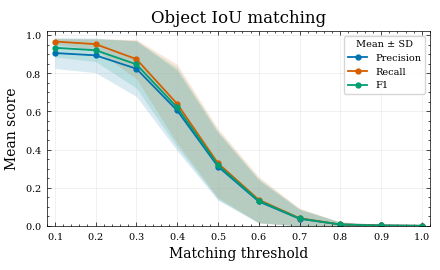

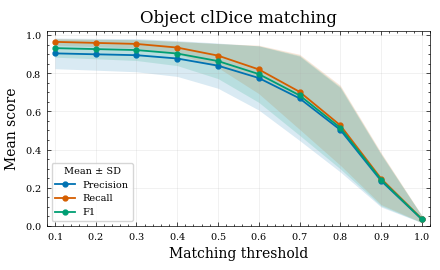

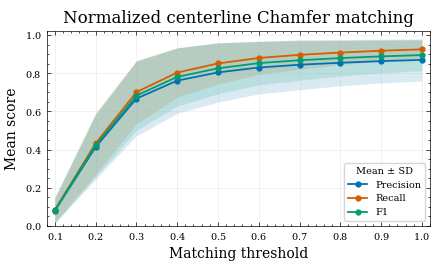

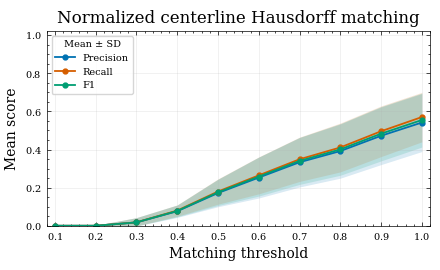

Threshold figures created: 4


In [18]:
import scienceplots


METRIC_LABELS = {
    "iou": "Object IoU matching",
    "cldice": "Object clDice matching",
    "centerline_chamfer_gt_width": (
        "Normalized centerline Chamfer matching"
    ),
    "centerline_hausdorff_gt_width": (
        "Normalized centerline Hausdorff matching"
    ),
}

METRIC_ORDER = [
    "iou",
    "cldice",
    "centerline_chamfer_gt_width",
    "centerline_hausdorff_gt_width",
]

THRESHOLD_FIGURE_SIZE = (
    4.5,
    2.8,
)

SCORE_COLUMNS = {
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1_score",
}

SCORE_COLORS = {
    "Precision": "#0072B2",
    "Recall": "#D55E00",
    "F1": "#009E73",
}


threshold_figures = {}


for matching_metric in METRIC_ORDER:
    metric_table = (
        per_image_metrics_df.loc[
            per_image_metrics_df[
                "matching_metric"
            ].eq(
                matching_metric
            )
        ]
        .copy()
    )


    image_counts = (
        metric_table
        .groupby(
            "threshold"
        )["filename"]
        .nunique()
    )

    if (
        len(image_counts) != 10
        or not image_counts.eq(12).all()
    ):
        raise RuntimeError(
            f"{matching_metric}: expected "
            "12 images at each of 10 thresholds."
        )


    with plt.style.context(
        [
            "science",
            "no-latex",
        ]
    ):
        figure, axis = plt.subplots(
            figsize=THRESHOLD_FIGURE_SIZE,
        )


        for (
            score_label,
            score_column,
        ) in SCORE_COLUMNS.items():

            score_summary = (
                metric_table
                .groupby(
                    "threshold"
                )[score_column]
                .agg(
                    [
                        "mean",
                        "std",
                    ]
                )
                .sort_index()
            )


            thresholds = (
                score_summary.index
                .to_numpy(dtype=float)
            )

            means = (
                score_summary["mean"]
                .to_numpy(dtype=float)
            )

            standard_deviations = (
                score_summary["std"]
                .to_numpy(dtype=float)
            )


            lower_bound = np.clip(
                means
                - standard_deviations,
                0.0,
                1.0,
            )

            upper_bound = np.clip(
                means
                + standard_deviations,
                0.0,
                1.0,
            )


            color = SCORE_COLORS[
                score_label
            ]


            axis.plot(
                thresholds,
                means,
                marker="o",
                markersize=3.5,
                linewidth=1.3,
                color=color,
                label=score_label,
            )

            axis.fill_between(
                thresholds,
                lower_bound,
                upper_bound,
                color=color,
                alpha=0.15,
                linewidth=0,
            )


        axis.set_title(
            METRIC_LABELS[
                matching_metric
            ]
        )

        axis.set_xlabel(
            "Matching threshold"
        )

        axis.set_ylabel(
            "Mean score"
        )


        axis.set_xticks(
            np.arange(
                0.1,
                1.01,
                0.1,
            )
        )

        axis.set_yticks(
            np.arange(
                0.0,
                1.01,
                0.2,
            )
        )


        axis.set_xlim(
            0.08,
            1.02,
        )

        axis.set_ylim(
            0.0,
            1.02,
        )


        axis.tick_params(
            axis="both",
            labelsize=7,
        )

        axis.grid(
            alpha=0.25,
        )

        axis.legend(
            title="Mean ± SD",
            fontsize=7,
            title_fontsize=7,
            frameon=True,
        )


        figure.tight_layout()


    threshold_figures[
        matching_metric
    ] = figure

    plt.show()


print(
    "Threshold figures created:",
    len(threshold_figures),
)

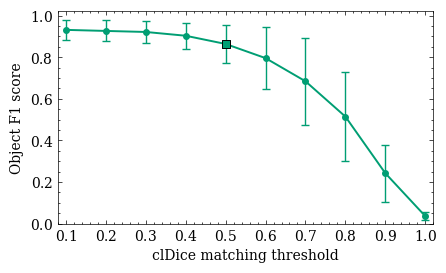

At clDice = 0.5:
Mean F1 = 0.8634
Standard deviation = 0.0917
Images = 12

Saved SVG:
c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\huuman_annotations\human_annotator_cldice_object_f1.svg

Saved PNG:
c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\huuman_annotations\human_annotator_cldice_object_f1.png


In [22]:
from pathlib import Path


cldice_f1_table = (
    per_image_metrics_df.loc[
        per_image_metrics_df[
            "matching_metric"
        ].eq(
            "cldice"
        )
    ]
    .groupby(
        "threshold"
    )["f1_score"]
    .agg(
        [
            "mean",
            "std",
            "count",
        ]
    )
    .sort_index()
)


if (
    len(cldice_f1_table) != 10
    or not cldice_f1_table[
        "count"
    ].eq(12).all()
):
    raise RuntimeError(
        "Expected 12 image-level clDice F1 "
        "values at each of 10 thresholds."
    )


thresholds = (
    cldice_f1_table.index
    .to_numpy(dtype=float)
)

mean_f1 = (
    cldice_f1_table["mean"]
    .to_numpy(dtype=float)
)

std_f1 = (
    cldice_f1_table["std"]
    .to_numpy(dtype=float)
)


f1_at_0p5 = (
    cldice_f1_table.loc[
        0.5
    ]
)


with plt.style.context(
    [
        "science",
        "no-latex",
    ]
):
    cldice_f1_figure, axis = (
        plt.subplots(
            figsize=THRESHOLD_FIGURE_SIZE,
        )
    )


    axis.errorbar(
        thresholds,
        mean_f1,
        yerr=std_f1,
        color="#009E73",
        marker="o",
        markersize=4,
        linewidth=1.4,
        linestyle="-",
        ecolor="#009E73",
        elinewidth=1.0,
        capsize=3,
        capthick=1.0,
        label="Mean object F1 ± SD",
    )


    axis.scatter(
        0.5,
        f1_at_0p5["mean"],
        marker="s",
        s=28,
        facecolor="#009E73",
        edgecolor="black",
        linewidth=0.7,
        zorder=5,
    )


    axis.set_xlabel(
        "clDice matching threshold"
    )

    axis.set_ylabel(
        "Object F1 score"
    )


    axis.set_xticks(
        np.arange(
            0.1,
            1.01,
            0.1,
        )
    )

    axis.set_yticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )

    axis.set_xlim(
        0.08,
        1.02,
    )

    axis.set_ylim(
        0.0,
        1.02,
    )


    cldice_f1_figure.tight_layout()


    # Save in the same working directory as the notebook.
    output_directory = Path.cwd()

    svg_path = (
        output_directory
        / "human_annotator_cldice_object_f1.svg"
    )

    png_path = (
        output_directory
        / "human_annotator_cldice_object_f1.png"
    )


    cldice_f1_figure.savefig(
        svg_path,
        format="svg",
        bbox_inches="tight",
        pad_inches=0.02,
    )

    cldice_f1_figure.savefig(
        png_path,
        format="png",
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02,
    )


plt.show()


print(
    "At clDice = 0.5:"
)

print(
    f"Mean F1 = "
    f"{f1_at_0p5['mean']:.4f}"
)

print(
    f"Standard deviation = "
    f"{f1_at_0p5['std']:.4f}"
)

print(
    f"Images = "
    f"{int(f1_at_0p5['count'])}"
)

print()
print("Saved SVG:")
print(svg_path)

print()
print("Saved PNG:")
print(png_path)

## Object-metric summaries over selected threshold ranges


In [ ]:
OBJECT_SUMMARY_COLUMNS = [
    "mean_precision",
    "mean_recall",
    "mean_f1",
    "mean_dsb_precision",
    "mean_absolute_length_error_um",
    "mean_absolute_relative_length_error",
    "mean_absolute_orientation_error_deg",
]


threshold_selections = {
    "all_thresholds_0p1_to_1p0": (
        dataset_summary_df[
            "threshold"
        ].between(
            0.1,
            1.0,
            inclusive="both",
        )
    ),
    "thresholds_0p5_to_1p0": (
        dataset_summary_df[
            "threshold"
        ].between(
            0.5,
            1.0,
            inclusive="both",
        )
    ),
    "threshold_0p5": (
        np.isclose(
            dataset_summary_df[
                "threshold"
            ],
            0.5,
        )
    ),
}


object_summary_rows = []


for (
    threshold_scope,
    selection,
) in threshold_selections.items():
    selected_table = (
        dataset_summary_df.loc[
            selection
        ]
    )

    for matching_metric in (
        METRIC_ORDER
    ):
        metric_table = (
            selected_table.loc[
                selected_table[
                    "matching_metric"
                ].eq(
                    matching_metric
                )
            ]
        )

        if metric_table.empty:
            raise RuntimeError(
                f"No rows found for "
                f"{matching_metric}, "
                f"{threshold_scope}."
            )

        row = {
            "matching_metric": (
                matching_metric
            ),
            "metric_label": (
                METRIC_LABELS[
                    matching_metric
                ]
            ),
            "threshold_scope": (
                threshold_scope
            ),
            "threshold_min": float(
                metric_table[
                    "threshold"
                ].min()
            ),
            "threshold_max": float(
                metric_table[
                    "threshold"
                ].max()
            ),
            "threshold_count": int(
                metric_table[
                    "threshold"
                ].nunique()
            ),
            "number_of_images": int(
                metric_table[
                    "number_of_images"
                ].max()
            ),
        }

        for column in (
            OBJECT_SUMMARY_COLUMNS
        ):
            row[column] = float(
                metric_table[
                    column
                ].mean()
            )

        object_summary_rows.append(
            row
        )


object_threshold_summary_df = (
    pd.DataFrame(
        object_summary_rows
    )
)


object_threshold_summary_df[
    "matching_metric"
] = pd.Categorical(
    object_threshold_summary_df[
        "matching_metric"
    ],
    categories=METRIC_ORDER,
    ordered=True,
)

object_threshold_summary_df = (
    object_threshold_summary_df
    .sort_values(
        [
            "threshold_scope",
            "matching_metric",
        ]
    )
    .reset_index(drop=True)
)


display(
    object_threshold_summary_df
)

,matching_metric,metric_label,threshold_scope,threshold_min,threshold_max,threshold_count,number_of_images,mean_precision,mean_recall,mean_f1,mean_dsb_precision,mean_absolute_length_error_um,mean_absolute_relative_length_error,mean_absolute_orientation_error_deg
0,iou,Object IoU matching,all_thresholds_0p1_to_1p0,0.1,1.0,10,12,0.371508,0.394847,0.382144,0.326742,0.051435,0.137073,1.590476
1,cldice,Object clDice matching,all_thresholds_0p1_to_1p0,0.1,1.0,10,12,0.663078,0.703597,0.681593,0.596934,0.077825,0.187341,2.513320
2,centerline_chamfer_gt_width,Normalized centerline Chamfer matching,all_thresholds_0p1_to_1p0,0.1,1.0,10,12,0.698579,0.739676,0.717414,0.621087,0.067341,0.159399,2.184817
3,centerline_hausdorff_gt_width,Normalized centerline Hausdorff matching,all_thresholds_0p1_to_1p0,0.1,1.0,10,12,0.226277,0.237320,0.231353,0.149733,0.025702,0.062893,1.674919
4,iou,Object IoU matching,threshold_0p5,0.5,0.5,1,12,0.311350,0.328572,0.319156,0.202827,0.055892,0.164602,2.100147
5,cldice,Object clDice matching,threshold_0p5,0.5,0.5,1,12,0.839371,0.892002,0.863412,0.769970,0.091040,0.205239,2.623275
6,centerline_chamfer_gt_width,Normalized centerline Chamfer matching,threshold_0p5,0.5,0.5,1,12,0.803931,0.850822,0.825415,0.722016,0.071131,0.169475,2.293893
7,centerline_hausdorff_gt_width,Normalized centerline Hausdorff matching,threshold_0p5,0.5,0.5,1,12,0.172404,0.180232,0.176009,0.097951,0.022417,0.064577,1.884501
8,iou,Object IoU matching,thresholds_0p5_to_1p0,0.5,1.0,6,12,0.081394,0.086315,0.083614,0.050641,0.025277,0.089998,0.931110
9,cldice,Object clDice matching,thresholds_0p5_to_1p0,0.5,1.0,6,12,0.509561,0.537742,0.522460,0.423768,0.059974,0.154481,2.130130


In [ ]:
object_summary_display_df = (
    object_threshold_summary_df[
        [
            "metric_label",
            "threshold_scope",
            "mean_precision",
            "mean_recall",
            "mean_f1",
            "mean_dsb_precision",
            "mean_absolute_length_error_um",
            "mean_absolute_relative_length_error",
            "mean_absolute_orientation_error_deg",
        ]
    ]
    .copy()
)


numeric_columns = (
    object_summary_display_df
    .select_dtypes(
        include="number"
    )
    .columns
)

object_summary_display_df[
    numeric_columns
] = object_summary_display_df[
    numeric_columns
].round(4)


display(
    object_summary_display_df
)

,metric_label,threshold_scope,mean_precision,mean_recall,mean_f1,mean_dsb_precision,mean_absolute_length_error_um,mean_absolute_relative_length_error,mean_absolute_orientation_error_deg
0,Object IoU matching,all_thresholds_0p1_to_1p0,0.3715,0.3948,0.3821,0.3267,0.0514,0.1371,1.5905
1,Object clDice matching,all_thresholds_0p1_to_1p0,0.6631,0.7036,0.6816,0.5969,0.0778,0.1873,2.5133
2,Normalized centerline Chamfer matching,all_thresholds_0p1_to_1p0,0.6986,0.7397,0.7174,0.6211,0.0673,0.1594,2.1848
3,Normalized centerline Hausdorff matching,all_thresholds_0p1_to_1p0,0.2263,0.2373,0.2314,0.1497,0.0257,0.0629,1.6749
4,Object IoU matching,threshold_0p5,0.3114,0.3286,0.3192,0.2028,0.0559,0.1646,2.1001
5,Object clDice matching,threshold_0p5,0.8394,0.8920,0.8634,0.7700,0.0910,0.2052,2.6233
6,Normalized centerline Chamfer matching,threshold_0p5,0.8039,0.8508,0.8254,0.7220,0.0711,0.1695,2.2939
7,Normalized centerline Hausdorff matching,threshold_0p5,0.1724,0.1802,0.1760,0.0980,0.0224,0.0646,1.8845
8,Object IoU matching,thresholds_0p5_to_1p0,0.0814,0.0863,0.0836,0.0506,0.0253,0.0900,0.9311
9,Object clDice matching,thresholds_0p5_to_1p0,0.5096,0.5377,0.5225,0.4238,0.0600,0.1545,2.1301


## Pixel-level agreement summary


In [ ]:
PIXEL_SUMMARY_COLUMNS = [
    "num_gt_objects",
    "num_pred_objects",
    "pixel_precision",
    "pixel_recall",
    "pixel_f1",
    "pixel_fdr",
    "pixel_iou",
    "pixel_dice",
    "pixel_cldice",
]


pixel_summary_rows = []


for column in PIXEL_SUMMARY_COLUMNS:
    values = pd.to_numeric(
        pixel_metrics_df[column],
        errors="coerce",
    )

    pixel_summary_rows.append(
        {
            "metric": column,
            "mean": float(
                values.mean()
            ),
            "standard_deviation": float(
                values.std(
                    ddof=1
                )
            ),
            "minimum": float(
                values.min()
            ),
            "maximum": float(
                values.max()
            ),
            "number_of_images": int(
                values.notna().sum()
            ),
        }
    )


pixel_metrics_summary_df = (
    pd.DataFrame(
        pixel_summary_rows
    )
)


display(
    pixel_metrics_summary_df.round(4)
)

,metric,mean,standard_deviation,minimum,maximum,number_of_images
0,num_gt_objects,156.6667,125.5072,24.0000,320.0000,12
1,num_pred_objects,172.9167,139.9152,23.0000,350.0000,12
2,pixel_precision,0.8885,0.0995,0.5917,0.9650,12
3,pixel_recall,0.5103,0.0699,0.4410,0.6717,12
4,pixel_f1,0.6407,0.0419,0.5907,0.7220,12
5,pixel_fdr,0.1115,0.0995,0.0350,0.4083,12
6,pixel_iou,0.4727,0.0466,0.4192,0.5650,12
7,pixel_dice,0.6407,0.0419,0.5907,0.7220,12
8,pixel_cldice,0.8019,0.0518,0.6917,0.8733,12


## Images with lowest and highest pixel agreement

In [ ]:
AGREEMENT_METRIC = "pixel_dice"
NUMBER_OF_EXTREME_IMAGES = 3


lowest_agreement_df = (
    pixel_metrics_df
    .nsmallest(
        NUMBER_OF_EXTREME_IMAGES,
        AGREEMENT_METRIC,
    )
    .copy()
)

lowest_agreement_df.insert(
    0,
    "agreement_group",
    "Lowest agreement",
)


highest_agreement_df = (
    pixel_metrics_df
    .nlargest(
        NUMBER_OF_EXTREME_IMAGES,
        AGREEMENT_METRIC,
    )
    .copy()
)

highest_agreement_df.insert(
    0,
    "agreement_group",
    "Highest agreement",
)


extreme_agreement_df = (
    pd.concat(
        [
            lowest_agreement_df,
            highest_agreement_df,
        ],
        ignore_index=True,
    )
)


display(
    extreme_agreement_df[
        [
            "agreement_group",
            "filename",
            "num_gt_objects",
            "num_pred_objects",
            "pixel_precision",
            "pixel_recall",
            "pixel_dice",
            "pixel_iou",
            "pixel_cldice",
        ]
    ]
)

,agreement_group,filename,num_gt_objects,num_pred_objects,pixel_precision,pixel_recall,pixel_dice,pixel_iou,pixel_cldice
0,Lowest agreement,400-1605-W8_map_00006_top_right.tif,43,43,0.894372,0.440982,0.590708,0.419152,0.809824
1,Lowest agreement,400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif,297,331,0.953776,0.447782,0.609441,0.438271,0.746578
2,Lowest agreement,400-1605-W7_map_00028_top_left.tif,62,66,0.896637,0.463463,0.611070,0.439957,0.826937
3,Highest agreement,400-1293-18_cd_c11k4r9_fl1_0sp9_image_left.tif,258,270,0.965030,0.576813,0.722047,0.565003,0.854048
4,Highest agreement,400-1605-W8_map_00006_bottom_left.tif,49,50,0.882866,0.584491,0.703342,0.542427,0.862271
5,Highest agreement,400-1093-w17-c1p3-20sp-03flow_right.tif,309,350,0.929399,0.534526,0.678707,0.513668,0.804795



400-1605-W8_map_00006_top_right.tif
Pixel Dice: 0.5907
Pixel clDice: 0.8098
Common foreground pixels: 2066
Disagreement pixels: 2863


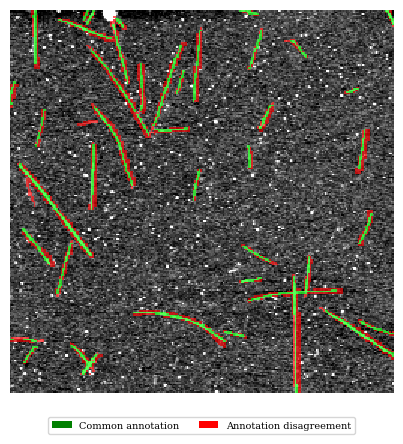


400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_right.tif
Pixel Dice: 0.6094
Pixel clDice: 0.7466
Common foreground pixels: 11658
Disagreement pixels: 14942


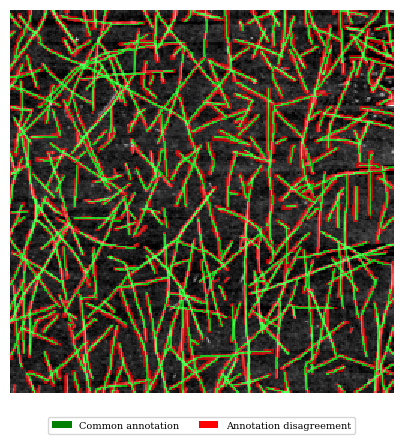


400-1605-W7_map_00028_top_left.tif
Pixel Dice: 0.6111
Pixel clDice: 0.8269
Common foreground pixels: 3279
Disagreement pixels: 4174


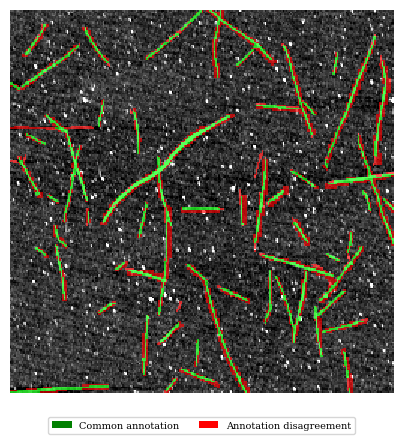


400-1605-W8_map_00038_bottom_right.tif
Pixel Dice: 0.6131
Pixel clDice: 0.8183
Common foreground pixels: 1849
Disagreement pixels: 2334


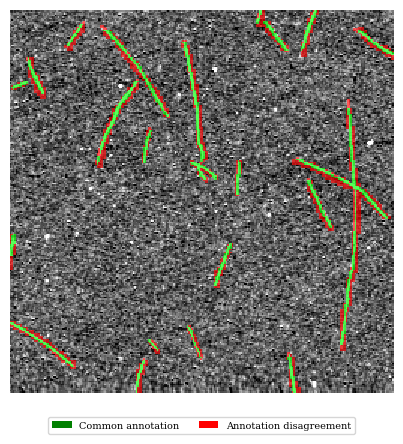


400-1093-w14-c-1-p1-10sp-15flow_left.tif
Pixel Dice: 0.6140
Pixel clDice: 0.7650
Common foreground pixels: 13664
Disagreement pixels: 17182


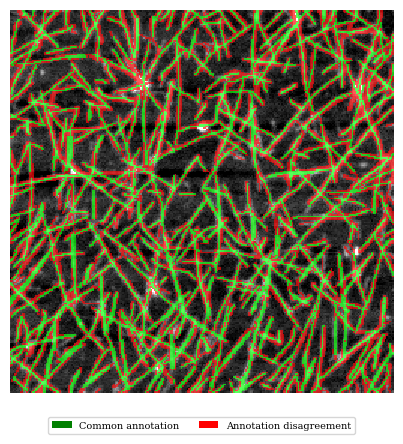


400-1605-W8_map_00006_bottom_right.tif
Pixel Dice: 0.6169
Pixel clDice: 0.7857
Common foreground pixels: 1727
Disagreement pixels: 2145


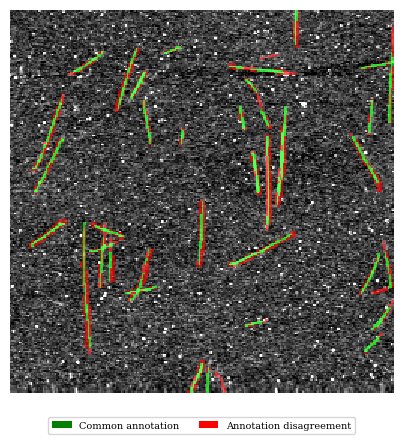


400-1293-21_3_0_20230206211107.tif
Pixel Dice: 0.6292
Pixel clDice: 0.6917
Common foreground pixels: 6083
Disagreement pixels: 7171


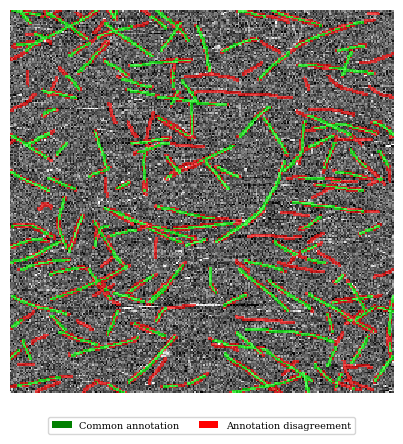


400-1605-W7_map_00028_bottom_left.tif
Pixel Dice: 0.6318
Pixel clDice: 0.8733
Common foreground pixels: 3187
Disagreement pixels: 3715


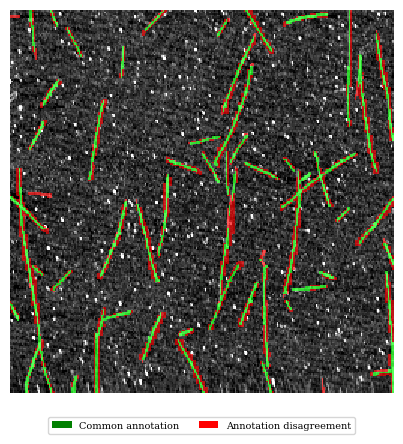


400-1293-18_cd_c1k40r9_fl3_0sp9_0_image_left.tif
Pixel Dice: 0.6681
Pixel clDice: 0.7846
Common foreground pixels: 11504
Disagreement pixels: 11430


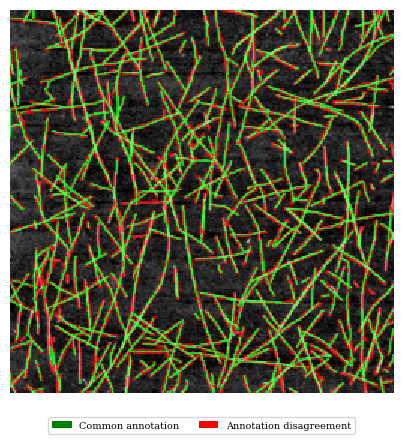


400-1093-w17-c1p3-20sp-03flow_right.tif
Pixel Dice: 0.6787
Pixel clDice: 0.8048
Common foreground pixels: 13717
Disagreement pixels: 12987


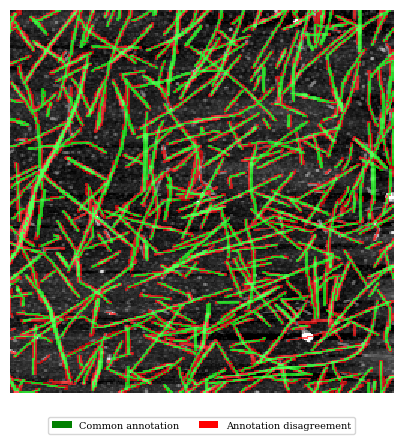


Figures created: 10


In [ ]:
import matplotlib.pyplot as plt
import scienceplots

from matplotlib.patches import Patch


NUMBER_OF_EXAMPLES = 10

FIGURE_SIZE = (
    4.5,
    4.5,
)

OVERLAY_ALPHA = 0.65


def normalize_image_for_display(
    image,
):
    """
    Normalize an image to [0, 1] using the
    1st and 99th percentiles.
    """
    image = np.asarray(
        image,
        dtype=np.float32,
    )

    finite_mask = np.isfinite(
        image
    )

    if not finite_mask.any():
        return np.zeros_like(
            image,
            dtype=np.float32,
        )

    finite_values = image[
        finite_mask
    ]

    lower = np.percentile(
        finite_values,
        1,
    )

    upper = np.percentile(
        finite_values,
        99,
    )

    if upper <= lower:
        lower = finite_values.min()
        upper = finite_values.max()

    if upper <= lower:
        return np.zeros_like(
            image,
            dtype=np.float32,
        )

    normalized = (
        image - lower
    ) / (
        upper - lower
    )

    return np.clip(
        normalized,
        0.0,
        1.0,
    )


def build_agreement_overlay(
    original_image,
    annotator_a_labels,
    annotator_b_labels,
    alpha=0.65,
):
    """
    Build a binary human-annotation agreement overlay.

    Green:
        foreground annotated by both annotators.

    Red:
        foreground annotated by only one annotator.

    Instance IDs are ignored here. Only foreground
    versus background is compared.
    """
    image = normalize_image_for_display(
        original_image
    )

    if image.ndim == 2:
        rgb_image = np.repeat(
            image[..., None],
            3,
            axis=2,
        )

    elif (
        image.ndim == 3
        and image.shape[2] >= 3
    ):
        rgb_image = image[
            ...,
            :3,
        ].copy()

    else:
        raise ValueError(
            f"Unsupported image shape: "
            f"{image.shape}"
        )


    mask_a = (
        np.asarray(
            annotator_a_labels
        )
        > 0
    )

    mask_b = (
        np.asarray(
            annotator_b_labels
        )
        > 0
    )


    common_mask = (
        mask_a
        & mask_b
    )

    disagreement_mask = (
        mask_a
        ^ mask_b
    )


    overlay = rgb_image.copy()


    green = np.array(
        [
            0.0,
            1.0,
            0.0,
        ],
        dtype=np.float32,
    )

    red = np.array(
        [
            1.0,
            0.0,
            0.0,
        ],
        dtype=np.float32,
    )


    overlay[
        common_mask
    ] = (
        (
            1.0 - alpha
        )
        * overlay[
            common_mask
        ]
        + alpha
        * green
    )


    overlay[
        disagreement_mask
    ] = (
        (
            1.0 - alpha
        )
        * overlay[
            disagreement_mask
        ]
        + alpha
        * red
    )


    return (
        overlay,
        common_mask,
        disagreement_mask,
    )


# Select the three images with the lowest
# pixel Dice, i.e. strongest annotation disagreement.
selected_images_df = (
    pixel_metrics_df
    .sort_values(
        "pixel_dice",
        ascending=True,
    )
    .head(
        NUMBER_OF_EXAMPLES
    )
    .reset_index(
        drop=True
    )
)


legend_handles = [
    Patch(
        facecolor="green",
        edgecolor="none",
        label="Common annotation",
    ),
    Patch(
        facecolor="red",
        edgecolor="none",
        label="Annotation disagreement",
    ),
]


agreement_figures = {}


for _, row in (
    selected_images_df.iterrows()
):
    filename = Path(
        row["filename"]
    ).name

    key = pairing_key(
        Path(filename)
    )


    if key not in image_index:
        raise RuntimeError(
            f"Cannot resolve image: "
            f"{filename}"
        )


    original_image = np.asarray(
        tifffile.imread(
            image_index[key]
        )
    )

    annotator_a_labels = np.asarray(
        tifffile.imread(
            annotator_a_index[key]
        )
    )

    annotator_b_labels = np.asarray(
        tifffile.imread(
            annotator_b_index[key]
        )
    )


    if not (
        original_image.shape[:2]
        == annotator_a_labels.shape
        == annotator_b_labels.shape
    ):
        raise RuntimeError(
            f"Shape mismatch for "
            f"{filename}: "
            f"image={original_image.shape}, "
            f"A={annotator_a_labels.shape}, "
            f"B={annotator_b_labels.shape}."
        )


    (
        agreement_overlay,
        common_mask,
        disagreement_mask,
    ) = build_agreement_overlay(
        original_image,
        annotator_a_labels,
        annotator_b_labels,
        alpha=OVERLAY_ALPHA,
    )


    with plt.style.context(
        [
            "science",
            "no-latex",
        ]
    ):
        figure, axis = plt.subplots(
            figsize=FIGURE_SIZE,
        )


        axis.imshow(
            agreement_overlay,
            interpolation="nearest",
        )

        axis.axis(
            "off"
        )


        # axis.set_title(
        #     (
        #         f"{filename}\n"
        #         f"Dice = "
        #         f"{float(row['pixel_dice']):.3f}, "
        #         f"clDice = "
        #         f"{float(row['pixel_cldice']):.3f}"
        #     ),
        #     fontsize=9,
        # )


        axis.legend(
            handles=legend_handles,
            loc="lower center",
            bbox_to_anchor=(
                0.5,
                -0.12,
            ),
            ncol=2,
            fontsize=7,
            frameon=True,
        )


        figure.tight_layout()


    filename_stem = Path(
        filename
    ).stem

    agreement_figures[
        filename_stem
    ] = figure


    print()
    print(
        filename
    )

    print(
        "Pixel Dice:",
        f"{float(row['pixel_dice']):.4f}",
    )

    print(
        "Pixel clDice:",
        f"{float(row['pixel_cldice']):.4f}",
    )

    print(
        "Common foreground pixels:",
        int(
            common_mask.sum()
        ),
    )

    print(
        "Disagreement pixels:",
        int(
            disagreement_mask.sum()
        ),
    )


    plt.show()


print()
print(
    "Figures created:",
    len(
        agreement_figures
    ),
)

## Save final human-agreement results

In [ ]:
HUMAN_AGREEMENT_RESULTS_DIR = (
    OUTPUT_ROOT
    / "summary"
)

HUMAN_AGREEMENT_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


tables_to_save = {
    "object_metrics_threshold_summary.csv": (
        object_threshold_summary_df
    ),
    "object_metrics_dataset_summary.csv": (
        dataset_summary_df
    ),
    "pixel_metrics_summary.csv": (
        pixel_metrics_summary_df
    ),
    "pixel_metrics_per_image.csv": (
        pixel_metrics_df
    ),
    "extreme_agreement_images.csv": (
        extreme_agreement_df
    ),
}


for filename, table in (
    tables_to_save.items()
):
    table.to_csv(
        HUMAN_AGREEMENT_RESULTS_DIR
        / filename,
        index=False,
    )


threshold_figure.savefig(
    HUMAN_AGREEMENT_RESULTS_DIR
    / "object_metrics_across_thresholds.png",
    dpi=300,
    bbox_inches="tight",
)

threshold_figure.savefig(
    HUMAN_AGREEMENT_RESULTS_DIR
    / "object_metrics_across_thresholds.pdf",
    bbox_inches="tight",
)


agreement_figure.savefig(
    HUMAN_AGREEMENT_RESULTS_DIR
    / "lowest_highest_agreement_images.png",
    dpi=300,
    bbox_inches="tight",
)

agreement_figure.savefig(
    HUMAN_AGREEMENT_RESULTS_DIR
    / "lowest_highest_agreement_images.pdf",
    bbox_inches="tight",
)


metadata = {
    "annotator_a_role": "ground_truth",
    "annotator_b_role": "prediction",
    "image_count": int(
        len(pixel_metrics_df)
    ),
    "annotator_a_object_count": int(
        pixel_metrics_df[
            "num_gt_objects"
        ].sum()
    ),
    "annotator_b_object_count": int(
        pixel_metrics_df[
            "num_pred_objects"
        ].sum()
    ),
    "matching_metrics": (
        METRIC_ORDER
    ),
    "similarity_thresholds": [
        0.1,
        0.2,
        0.3,
        0.4,
        0.5,
        0.6,
        0.7,
        0.8,
        0.9,
        1.0,
    ],
    "extreme_image_ranking_metric": (
        AGREEMENT_METRIC
    ),
    "extreme_images_per_group": int(
        NUMBER_OF_EXTREME_IMAGES
    ),
    "interpretation_note": (
        "IoU and clDice become stricter as "
        "threshold increases. Centerline-distance "
        "matching becomes more permissive as its "
        "threshold increases."
    ),
}


metadata_path = (
    HUMAN_AGREEMENT_RESULTS_DIR
    / "human_agreement_summary_metadata.json"
)

metadata_path.write_text(
    json.dumps(
        metadata,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


print(
    "Results directory:",
    HUMAN_AGREEMENT_RESULTS_DIR,
)

print()
print("Saved files:")

for path in sorted(
    HUMAN_AGREEMENT_RESULTS_DIR.iterdir()
):
    print(
        f"  {path.name}"
    )

print()
print(
    "PASS: final human-annotation "
    "agreement results saved."
)

NameError: name 'threshold_figure' is not defined

## Human–human agreement table for the manuscript
Object metrics use one-to-one matching at clDice >= 0.5.
Pixel metrics compare the complete binary foreground masks.


In [ ]:
OBJECT_MATCHING_METRIC = "cldice"


cldice_metrics_df = (
    per_image_metrics_df.loc[
        per_image_metrics_df[
            "matching_metric"
        ].eq(
            OBJECT_MATCHING_METRIC
        )
    ]
    .copy()
)


threshold_scopes = {
    "clDice = 0.5": (
        np.isclose(
            cldice_metrics_df[
                "threshold"
            ],
            0.5,
        ),
        1,
    ),
    "Mean, clDice 0.5–1.0": (
        cldice_metrics_df[
            "threshold"
        ].between(
            0.5,
            1.0,
            inclusive="both",
        ),
        6,
    ),
    "Mean, clDice 0.1–1.0": (
        cldice_metrics_df[
            "threshold"
        ].between(
            0.1,
            1.0,
            inclusive="both",
        ),
        10,
    ),
}


object_metric_columns = {
    "Precision": "precision",
    "Recall": "recall",
    "F1 score": "f1_score",
    "DSB precision": "dsb_precision",
}


pixel_metric_columns = {
    "Precision": "pixel_precision",
    "Recall": "pixel_recall",
    "Dice": "pixel_dice",
    "IoU": "pixel_iou",
    "clDice": "pixel_cldice",
}


numeric_rows = []


for scope_name, (
    selection,
    expected_threshold_count,
) in threshold_scopes.items():

    scope_df = (
        cldice_metrics_df.loc[
            selection
        ]
        .copy()
    )


    actual_threshold_count = (
        scope_df[
            "threshold"
        ].nunique()
    )

    if (
        actual_threshold_count
        != expected_threshold_count
    ):
        raise RuntimeError(
            f"{scope_name}: expected "
            f"{expected_threshold_count} thresholds; "
            f"found {actual_threshold_count}."
        )


    image_threshold_counts = (
        scope_df
        .groupby(
            "filename"
        )["threshold"]
        .nunique()
    )

    if (
        len(image_threshold_counts) != 12
        or not image_threshold_counts.eq(
            expected_threshold_count
        ).all()
    ):
        raise RuntimeError(
            f"{scope_name}: some images do not "
            "contain the expected thresholds."
        )


    for (
        metric_label,
        metric_column,
    ) in object_metric_columns.items():

        image_values = (
            scope_df
            .groupby(
                "filename"
            )[metric_column]
            .mean()
        )

        numeric_rows.append(
            {
                "Evaluation level": (
                    "Object level"
                ),
                "Metric": metric_label,
                "Scope": scope_name,
                "Mean": float(
                    image_values.mean()
                ),
                "Standard deviation": float(
                    image_values.std(
                        ddof=1
                    )
                ),
                "Number of images": int(
                    image_values.notna().sum()
                ),
                "Threshold count": int(
                    expected_threshold_count
                ),
            }
        )


for (
    metric_label,
    metric_column,
) in pixel_metric_columns.items():

    values = pd.to_numeric(
        pixel_metrics_df[
            metric_column
        ],
        errors="coerce",
    )

    if values.notna().sum() != 12:
        raise RuntimeError(
            f"Pixel-level {metric_label} does "
            "not contain 12 valid values."
        )

    numeric_rows.append(
        {
            "Evaluation level": (
                "Pixel level"
            ),
            "Metric": metric_label,
            "Scope": (
                "Complete binary foreground masks"
            ),
            "Mean": float(
                values.mean()
            ),
            "Standard deviation": float(
                values.std(
                    ddof=1
                )
            ),
            "Number of images": int(
                values.notna().sum()
            ),
            "Threshold count": np.nan,
        }
    )


human_agreement_numeric_df = (
    pd.DataFrame(
        numeric_rows
    )
)


human_agreement_numeric_df[
    "Mean ± SD"
] = (
    human_agreement_numeric_df.apply(
        lambda row: (
            f"{row['Mean']:.3f} ± "
            f"{row['Standard deviation']:.3f}"
        ),
        axis=1,
    )
)


object_display_df = (
    human_agreement_numeric_df.loc[
        human_agreement_numeric_df[
            "Evaluation level"
        ].eq(
            "Object level"
        )
    ]
    .pivot(
        index=[
            "Evaluation level",
            "Metric",
        ],
        columns="Scope",
        values="Mean ± SD",
    )
    .reset_index()
)


pixel_display_df = (
    human_agreement_numeric_df.loc[
        human_agreement_numeric_df[
            "Evaluation level"
        ].eq(
            "Pixel level"
        ),
        [
            "Evaluation level",
            "Metric",
            "Mean ± SD",
        ],
    ]
    .rename(
        columns={
            "Mean ± SD": (
                "Pixel agreement"
            )
        }
    )
)


for column in [
    "clDice = 0.5",
    "Mean, clDice 0.5–1.0",
    "Mean, clDice 0.1–1.0",
]:
    pixel_display_df[
        column
    ] = "Not applicable"


object_display_df[
    "Pixel agreement"
] = "Not applicable"


human_agreement_manuscript_df = (
    pd.concat(
        [
            object_display_df,
            pixel_display_df,
        ],
        ignore_index=True,
    )
    [
        [
            "Evaluation level",
            "Metric",
            "clDice = 0.5",
            "Mean, clDice 0.5–1.0",
            "Mean, clDice 0.1–1.0",
            "Pixel agreement",
        ]
    ]
)


display(
    human_agreement_manuscript_df
)


numeric_table_path = (
    HUMAN_AGREEMENT_RESULTS_DIR
    / "human_agreement_manuscript_metrics.csv"
)

display_table_path = (
    HUMAN_AGREEMENT_RESULTS_DIR
    / "human_agreement_manuscript_table.csv"
)


human_agreement_numeric_df.to_csv(
    numeric_table_path,
    index=False,
)

human_agreement_manuscript_df.to_csv(
    display_table_path,
    index=False,
)


print()
print(
    "Numeric table:",
    numeric_table_path,
)

print(
    "Word-ready table:",
    display_table_path,
)

,Evaluation level,Metric,clDice = 0.5,"Mean, clDice 0.5–1.0","Mean, clDice 0.1–1.0",Pixel agreement
0,Object level,DSB precision,0.770 ± 0.140,0.424 ± 0.142,0.597 ± 0.118,Not applicable
1,Object level,F1 score,0.863 ± 0.092,0.522 ± 0.131,0.682 ± 0.097,Not applicable
2,Object level,Precision,0.839 ± 0.118,0.510 ± 0.141,0.663 ± 0.115,Not applicable
3,Object level,Recall,0.892 ± 0.063,0.538 ± 0.120,0.704 ± 0.079,Not applicable
4,Pixel level,Precision,Not applicable,Not applicable,Not applicable,0.888 ± 0.099
5,Pixel level,Recall,Not applicable,Not applicable,Not applicable,0.510 ± 0.070
6,Pixel level,Dice,Not applicable,Not applicable,Not applicable,0.641 ± 0.042
7,Pixel level,IoU,Not applicable,Not applicable,Not applicable,0.473 ± 0.047
8,Pixel level,clDice,Not applicable,Not applicable,Not applicable,0.802 ± 0.052



Numeric table: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\human_annotator_agreement\summary\human_agreement_manuscript_metrics.csv
Word-ready table: c:\Users\abd93000\PycharmProjects\cnt_project_v2\global_outputs\runs\human_annotator_agreement\summary\human_agreement_manuscript_table.csv
